# Understanding the Impact of State Level Funding on Student Outcomes
## CS 1090A Final Project
### by Alex Fernand, Moniola, Grace Augustine, and Garland Catlette

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.utils import resample
from scipy.stats import t

## Exploratory Data Analysis

In [61]:
df = pd.read_excel("data/StateIndicatorsDatabase_2025.xlsx", sheet_name="Data")

# Filtering data for the years 2009 to 2019 to address missingness
df = df[(df["year"] >= 2009) & (df["year"] <= 2019)]
df.head()

/Users/garlandcatlette/FALL25/CS_1090A/final_project/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,year,stabbr,state_name,statefip,region4,region9,effort,inc_effort,predicted_fedrevpp0_,predicted_fedrevpp10_,...,inc_gap130_ratio,coverage,state_chartershare,inc_pubsch,inc_nonpubsch,pubprv_incratio,case,citation,ruling,casetype
153,2019,AL,Alabama,1,South,East South Central,0.035605,0.038865,431.6210,686.7686,...,0.197983,0.861250,0.000795,82750.59,125697.30,0.658332,NaN,NaN,NaN,NaN
154,2019,AK,Alaska,2,West,Pacific,0.042915,0.053074,753.8663,1773.2300,...,0.225739,0.853597,0.055628,98056.77,87579.52,1.119631,NaN,NaN,NaN,NaN
155,2019,AZ,Arizona,4,West,Mountain,0.026370,0.029332,325.9877,613.1902,...,0.196911,0.895027,0.306565,101541.70,127656.70,0.795428,NaN,NaN,NaN,NaN
156,2019,AR,Arkansas,5,South,West South Central,0.042158,0.042279,512.3929,779.2733,...,0.214611,0.902905,0.075659,79239.53,120330.90,0.658514,NaN,NaN,NaN,NaN
157,2019,CA,California,6,West,Pacific,0.031838,0.038167,421.1313,749.0176,...,0.164208,0.901418,0.141387,125382.30,209634.50,0.598100,NaN,NaN,NaN,NaN


In [62]:
predictors_of_interest = ["year", "state_name", "stabbr", "region4", "region9", "effort", "inc_effort", "necm_ppcstot_state", "necm_fundinggap_state", "tchsalary25_30", "tchsalary31_40", "tchsalary41_50", "tchsalary51_60"]
response_var = "necm_outcomegap_state"

#Removed states with missing data for the response variable (Vermont, Alaska, Hawaii)
filtered_df = df[predictors_of_interest + [response_var]].dropna(subset=[response_var]).reset_index(drop=True)
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   528 non-null    int64  
 1   state_name             528 non-null    object 
 2   stabbr                 528 non-null    object 
 3   region4                528 non-null    object 
 4   region9                528 non-null    object 
 5   effort                 528 non-null    float64
 6   inc_effort             528 non-null    float64
 7   necm_ppcstot_state     528 non-null    float64
 8   necm_fundinggap_state  528 non-null    float64
 9   tchsalary25_30         528 non-null    float64
 10  tchsalary31_40         528 non-null    float64
 11  tchsalary41_50         528 non-null    float64
 12  tchsalary51_60         528 non-null    float64
 13  necm_outcomegap_state  528 non-null    float64
dtypes: float64(9), int64(1), object(4)
memory usage: 57.9+ KB


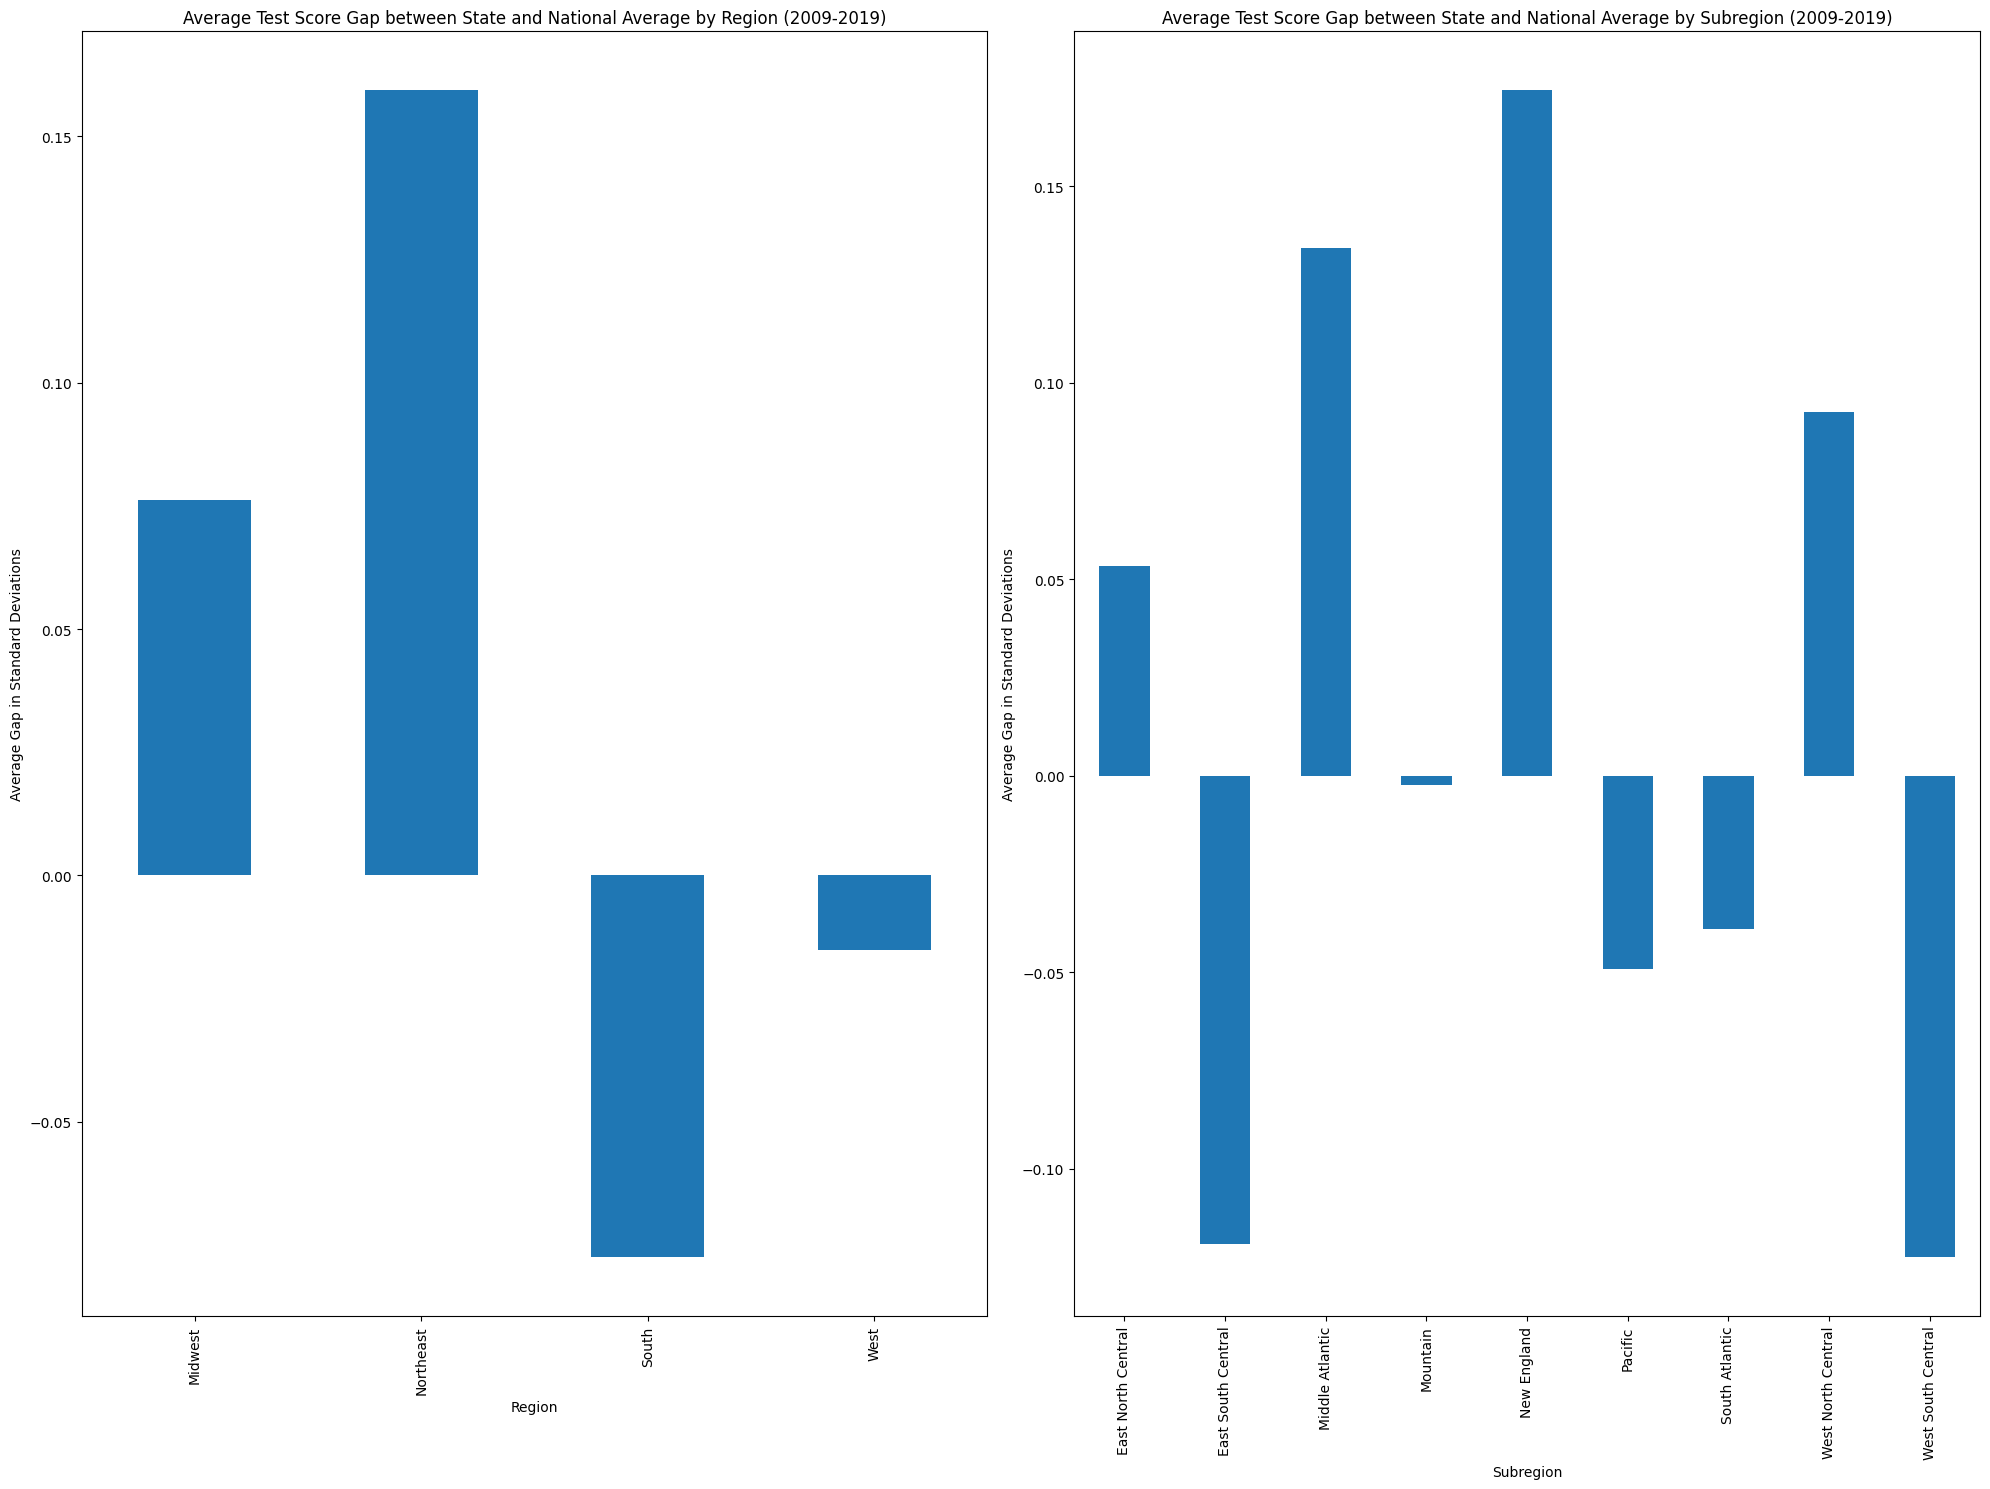

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(20, 15))

filtered_df.groupby("region4")[response_var].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Test Score Gap between State and National Average by Region (2009-2019)")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Average Gap in Standard Deviations")


filtered_df.groupby("region9")[response_var].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Test Score Gap between State and National Average by Subregion (2009-2019)")
axes[1].set_xlabel("Subregion")
axes[1].set_ylabel("Average Gap in Standard Deviations")
plt.tight_layout()
plt.show()

### Test Score Gap by State for years 2009 - 2019

##### Noteworthy Observations
* Test scores monotonically grow closer to the national average in Mississippi and the District of Columbia.
* New Hampshire consistently reports test scores above the national average, but test scores monotonically grow closer to the national average from 2013 - 2019.

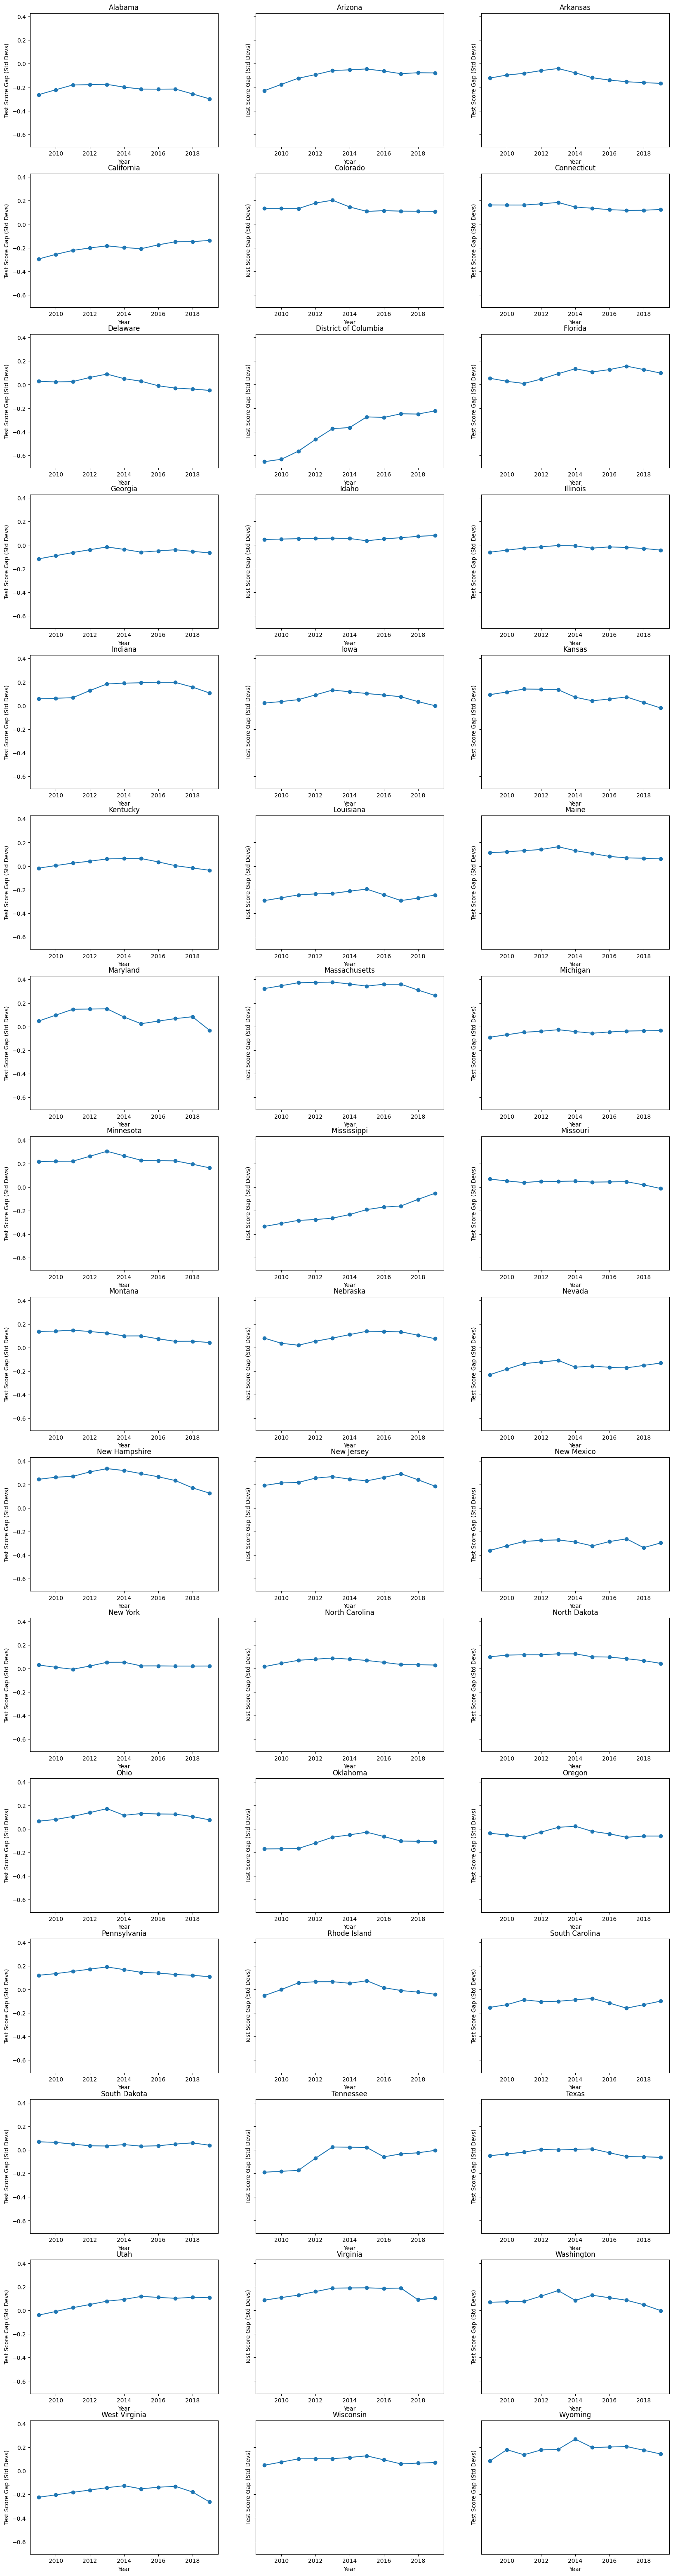

In [71]:
states = filtered_df["state_name"].unique()

fig, axes = plt.subplots(16, 3, figsize=(20, 80), sharey=True)

for state, ax in zip(states, axes.flatten()):
    state_data = filtered_df[filtered_df["state_name"] == state]
    ax.plot(state_data["year"], state_data[response_var], marker='o')
    ax.set_title(state)
    ax.set_xlabel("Year")
    ax.set_ylabel("Test Score Gap (Std Devs)")


In [75]:
filtered_df[filtered_df["region9"] == "West South Central"].head()

,year,state_name,stabbr,region4,region9,effort,inc_effort,necm_ppcstot_state,necm_fundinggap_state,tchsalary25_30,tchsalary31_40,tchsalary41_50,tchsalary51_60,necm_outcomegap_state
2,2019,Arkansas,AR,South,West South Central,0.042158,0.042279,10147.130,-3977.769,26109.33,30070.11,33990.20,37660.96,-0.167177
16,2019,Louisiana,LA,South,West South Central,0.031172,0.037213,11766.670,-4748.550,25750.54,30118.34,34771.75,39082.95,-0.245263
34,2019,Oklahoma,OK,South,West South Central,0.032601,0.036070,9307.067,-2510.214,22066.97,25086.94,28656.60,31428.53,-0.108837
41,2019,Texas,TX,South,West South Central,0.032217,0.039309,9728.912,-5719.424,25902.54,29966.43,34584.33,38601.39,-0.063338
50,2018,Arkansas,AR,South,West South Central,0.042203,0.041808,9927.650,-4558.711,24553.99,28190.38,32182.35,35485.43,-0.161231
